In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_security.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (9230, 13)


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,security_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [3]:
df_binary = df[df["security_label"].isin([0, 1])].copy()

df_binary["comment"] = (
    df_binary["comment"]
    .fillna("")
    .astype(str)
)

df_binary["label"] = df_binary["security_label"].astype(int)

df_binary = df_binary[
    ["comment", "label"]
].reset_index(drop=True)

print("Binary dataset shape:", df_binary.shape)
print(df_binary["label"].value_counts().sort_index())

Binary dataset shape: (9147, 2)
label
0    6119
1    3028
Name: count, dtype: int64


In [4]:
X = df_binary["comment"]
y = df_binary["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 7317
Testing rows: 1830


In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not security-related",
            "Security-related"
        ],
        zero_division=0
    )
)

Accuracy: 0.9759562841530055
Balanced accuracy: 0.9649461269656378
Precision: 0.9947183098591549
Recall: 0.9323432343234324
F1-score: 0.9625212947189097

Classification report:
                      precision    recall  f1-score   support

Not security-related       0.97      1.00      0.98      1224
    Security-related       0.99      0.93      0.96       606

            accuracy                           0.98      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.98      0.98      0.98      1830



In [6]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

feature_analysis = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_analysis["absolute_coefficient"] = (
    feature_analysis["coefficient"].abs()
)

feature_analysis = feature_analysis.sort_values(
    by="coefficient",
    ascending=False
).reset_index(drop=True)

display(feature_analysis.head(30))

,feature,coefficient,absolute_coefficient
0,vulnerability,5.593113,5.593113
1,csrf,5.437060,5.437060
2,exploit,5.103462,5.103462
3,vulnerable,4.995458,4.995458
4,security issue,4.668711,4.668711
5,xss,4.460366,4.460366
6,vulnerabilities,4.186037,4.186037
7,malicious,4.014494,4.014494
8,unauthorized,3.441190,3.441190
9,insecure,3.186864,3.186864


In [7]:
top_security_features = (
    feature_analysis
    .sort_values(
        by="coefficient",
        ascending=False
    )
    .head(30)
)

display(top_security_features)

,feature,coefficient,absolute_coefficient
0,vulnerability,5.593113,5.593113
1,csrf,5.437060,5.437060
2,exploit,5.103462,5.103462
3,vulnerable,4.995458,4.995458
4,security issue,4.668711,4.668711
5,xss,4.460366,4.460366
6,vulnerabilities,4.186037,4.186037
7,malicious,4.014494,4.014494
8,unauthorized,3.441190,3.441190
9,insecure,3.186864,3.186864


In [8]:
top_nonsecurity_features = (
    feature_analysis
    .sort_values(
        by="coefficient",
        ascending=True
    )
    .head(30)
)

display(top_nonsecurity_features)

,feature,coefficient,absolute_coefficient
14861,authorization,-4.211195,4.211195
14860,tls,-2.447100,2.447100
14859,credentials,-2.188238,2.188238
14858,token,-2.168054,2.168054
14857,permissions,-2.141165,2.141165
14856,password,-2.027512,2.027512
14855,secret,-1.958057,1.958057
14854,certificate,-1.944308,1.944308
14853,ssl,-1.804252,1.804252
14852,exploit fact,-1.726486,1.726486


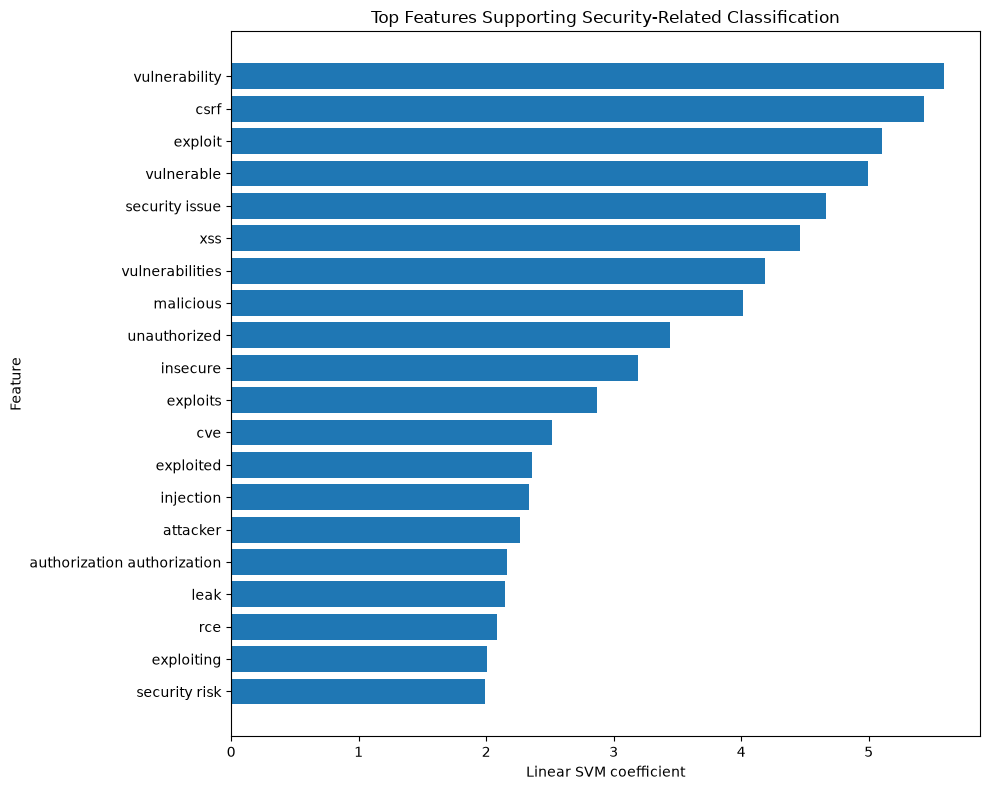

In [9]:
plot_data = (
    feature_analysis
    .sort_values(
        by="coefficient",
        ascending=False
    )
    .head(20)
    .sort_values(
        by="coefficient",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["feature"],
    plot_data["coefficient"]
)

plt.title("Top Features Supporting Security-Related Classification")
plt.xlabel("Linear SVM coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

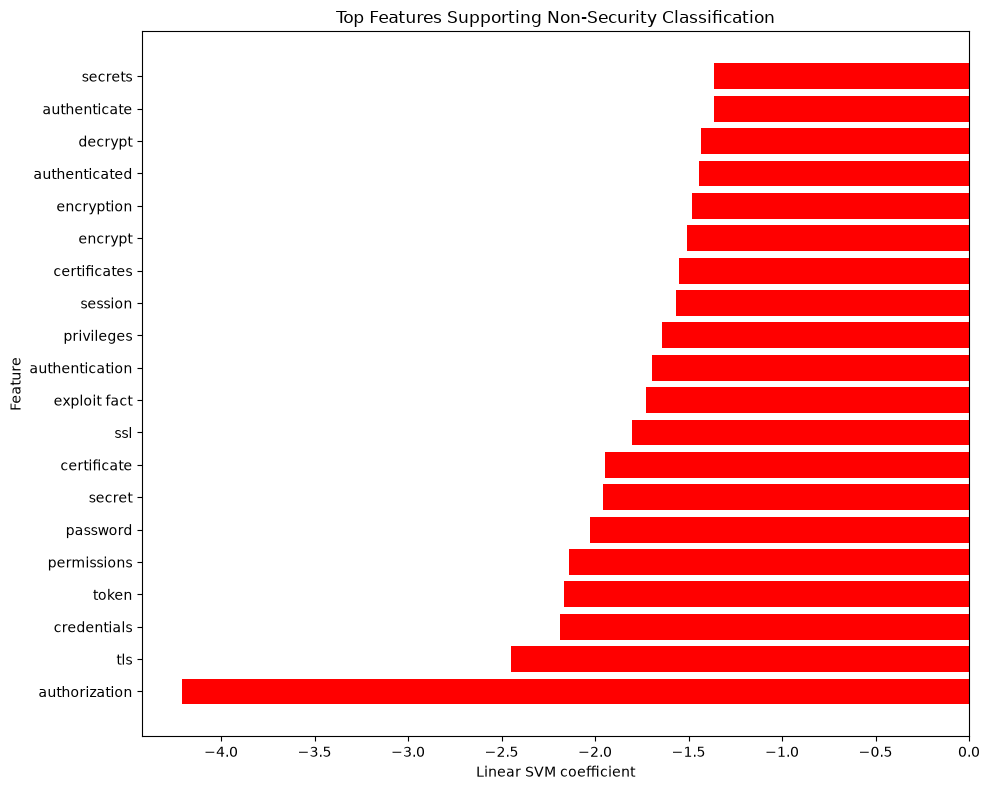

In [10]:
plot_data = (
    feature_analysis
    .sort_values(
        by="coefficient",
        ascending=True
    )
    .head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["feature"],
    plot_data["coefficient"],
    color="red"
)

plt.title("Top Features Supporting Non-Security Classification")
plt.xlabel("Linear SVM coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [11]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

feature_results_path = (
    RESULTS_DIR / "linear_svm_feature_coefficients.csv"
)

feature_analysis.to_csv(
    feature_results_path,
    index=False
)

print("Saved feature analysis to:")
print(feature_results_path)

Saved feature analysis to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/results/linear_svm_feature_coefficients.csv


In [12]:
print("Top 30 security-related features:")
display(
    feature_analysis
    .sort_values(by="coefficient", ascending=False)
    .head(30)
    [["feature", "coefficient"]]
)

print("\nTop 30 non-security features:")
display(
    feature_analysis
    .sort_values(by="coefficient", ascending=True)
    .head(30)
    [["feature", "coefficient"]]
)

Top 30 security-related features:


,feature,coefficient
0,vulnerability,5.593113
1,csrf,5.437060
2,exploit,5.103462
3,vulnerable,4.995458
4,security issue,4.668711
5,xss,4.460366
6,vulnerabilities,4.186037
7,malicious,4.014494
8,unauthorized,3.441190
9,insecure,3.186864



Top 30 non-security features:


,feature,coefficient
14861,authorization,-4.211195
14860,tls,-2.447100
14859,credentials,-2.188238
14858,token,-2.168054
14857,permissions,-2.141165
14856,password,-2.027512
14855,secret,-1.958057
14854,certificate,-1.944308
14853,ssl,-1.804252
14852,exploit fact,-1.726486
